# ORIE 4580/5580/5581 Assignment 6

#### Students: Xingwei Li(xl988)

### Github link: https://github.com/anthonyLi3317/orie5580/blob/main/HW6.ipynb


### Instructions


* Due Thursday, November 6, at 11.59pm on Gradescope.
* Assignment .ipynb files available for download on [Canvas](https://canvas.cornell.edu/courses/80773#:~:text=Assignments-,Assignments,-Assignments%20module%20publish). Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Do all your work in provided notebook (text answers typeset in markdown; show all required code and generate plots inline), and then generate and submit a pdf.
* Ideally do assignments in groups of 2, and submit a single pdf with both names
* Please show your work and clearly mark your answers.
* You can use any code fragments given in class, found online (for example, on StackOverflow), or generated via Gemini/Claude/ChatGPT (you are encouraged to use these for first drafts) **with proper referencing**.
* You can also discuss with others (again, please reference them if you do so); but you must write your final answers on your own as a team.



### Essential reading

The chapters on [Poisson Process](https://canvas.cornell.edu/courses/80773/modules/items/3269525), [DTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426077) and [CTMCs](https://canvas.cornell.edu/courses/80773/modules/items/3426086) from Mor Harchol-Balter, posted on Canvas

<hr><hr>

# Question 1 (The Spotify Shuffle)

**(a)** (10 pts) You have a Spotify playlist with $n$ songs playing on shuffle. Suppose Spotify truly picks a random song each time -- you want to see how many songs it takes on average to play **every song** on your playlist. Build a simulator to estimate this for a different values of $n$, and use this to try and guess the function.
	 
*Note 1*: We saw this in class as the `coupon collector' problem -- we also saw a way to compute the exact expected time in an earlier clicker question...

*Note 2*: Try and pick a large range of $n$ to get a sense of the function, and also make sure you always show your CIs!


<hr>

## Ans.

  0%|                                                     | 0/8 [00:00<?, ?it/s]

n=   5 → mean=11.46, 95% CI=(11.28, 11.64)


 25%|███████████▎                                 | 2/8 [00:00<00:00,  6.34it/s]

n=  10 → mean=29.42, 95% CI=(29.03, 29.81)


 38%|████████████████▉                            | 3/8 [00:00<00:01,  3.97it/s]

...

n= 200 → mean=1181.40, 95% CI=(1172.34, 1190.45)


 88%|███████████████████████████████████████▍     | 7/8 [00:29<00:07,  7.98s/it]

n= 500 → mean=3391.29, 95% CI=(3368.35, 3414.24)


100%|█████████████████████████████████████████████| 8/8 [01:10<00:00,  8.86s/it]

n=1000 → mean=7463.98, 95% CI=(7418.60, 7509.36)


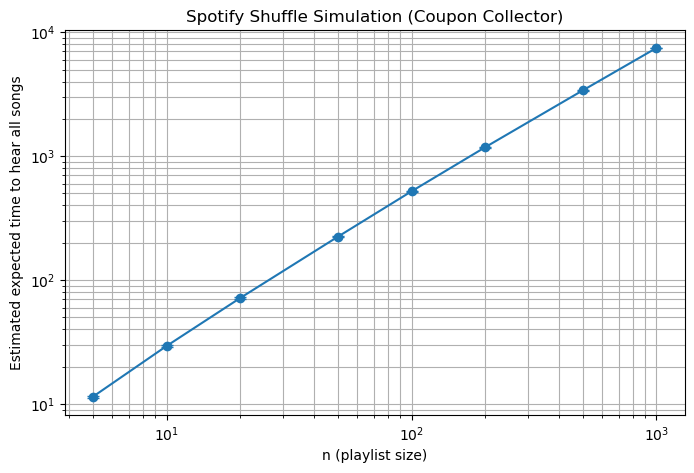

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def simulate_coupon_collector(n):
    heard = set()
    count = 0
    while len(heard) < n:
        song = np.random.randint(0, n)
        heard.add(song)
        count += 1
    return count

# Run many simulations + compute mean + 95% CI
def estimate_expectation(n, trials=3000):
    results = np.zeros(trials)
    for t in range(trials):
        results[t] = simulate_coupon_collector(n)
    mean = results.mean()
    std = results.std(ddof=1)
    ci_low  = mean - 1.96 * std / np.sqrt(trials)
    ci_high = mean + 1.96 * std / np.sqrt(trials)
    return mean, (ci_low, ci_high)

# Evaluate for a range of playlist sizes
ns = [5, 10, 20, 50, 100, 200, 500, 1000]
means = []
ci_lows = []
ci_highs = []

for n in tqdm(ns):
    mean, ci = estimate_expectation(n)
    means.append(mean)
    ci_lows.append(ci[0])
    ci_highs.append(ci[1])
    print(f"n={n:4d} → mean={mean:.2f}, 95% CI=({ci[0]:.2f}, {ci[1]:.2f})")


plt.figure(figsize=(8,5))
plt.errorbar(ns, means, yerr=[np.array(means)-np.array(ci_lows),
                              np.array(ci_highs)-np.array(means)],
             fmt='o-', capsize=4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (playlist size)")
plt.ylabel("Estimated expected time to hear all songs")
plt.title("Spotify Shuffle Simulation (Coupon Collector)")
plt.grid(True, which="both")
plt.show()

<hr>

**(b)** (10 pts) Suppose Spotify uses the following poor randomizer: it labels songs as $\{0,1,2,\ldots,n-1\}$, and after playing a song $i$, it then either plays song $(i+1) mod(n)$ or $(i-1)mod(n)$ with probability $1/2$ (i.e., the next or previous song, imagining the songs to be in a ring with $n-1$ wrapping around to $1$). Simulate this randomizer for $n=20$, assuming you always start at song $1$, and find the histogram of the *last song to be played* for the first time using this shuffler.   


<hr>

## Ans.

100%|████████████████████████████████████| 5000/5000 [00:00<00:00, 12619.00it/s]


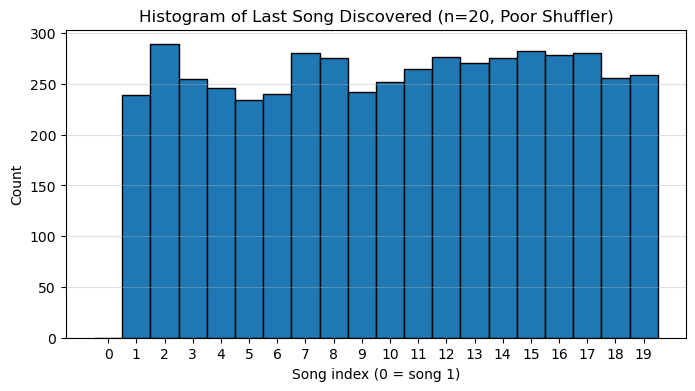

Frequencies of last-discovered songs:
Song 0: 0
Song 1: 239
Song 2: 289
Song 3: 255
Song 4: 246
Song 5: 234
Song 6: 240
Song 7: 281
Song 8: 276
Song 9: 242
Song 10: 252
Song 11: 265
Song 12: 277
Song 13: 271
Song 14: 276
Song 15: 282
Song 16: 279
Song 17: 281
Song 18: 256
Song 19: 259


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# Simulate the poor randomizer for n songs in a ring
def simulate_bad_shuffler(n):
    visited = set([0])       # start at song 0 (i.e., song 1)
    current = 0
    
    while len(visited) < n:
        # move either +1 or -1 modulo n
        if np.random.rand() < 0.5:
            current = (current + 1) % n
        else:
            current = (current - 1) % n
        
        visited.add(current)

    # The last song visited for the first time
    return current

# Run many trials to get the histogram
n = 20
trials = 5000
last_songs = np.zeros(trials, dtype=int)

for t in tqdm(range(trials)):
    last_songs[t] = simulate_bad_shuffler(n)

# Plot histogram of last songs
plt.figure(figsize=(8,4))
plt.hist(last_songs, bins=np.arange(-0.5, n+0.5, 1), edgecolor='black')
plt.xlabel("Song index (0 = song 1)")
plt.ylabel("Count")
plt.title("Histogram of Last Song Discovered (n=20, Poor Shuffler)")
plt.xticks(range(n))
plt.grid(axis='y', alpha=0.4)
plt.show()

# Print frequencies
counts = Counter(last_songs)
print("Frequencies of last-discovered songs:")
for song in range(n):
    print(f"Song {song}: {counts[song]}")

<hr><hr>

# Question 2 (The Gambler's Ruin)


In class, we saw the balanced gambler's ruin problem: two gambler's $A$ and $B$ start with $\$a$ and $\$b$ initially, and play a sequence of games, where each game is won by either player with probability $1/2$, with the winner giving $\$ 1$ to the loser. Play goes on till one player runs out of money. 

<hr>

**(a)** (5 pts) We argued that when both players have the same initial budget, then each player is equally likely to win. We now want to run a simulation to find a similar formula for general initial budgets. To do so, assume the total budget is $a+b=20$, and run simulations to find the expected probability that $A$ wins for all values of $a$ from $\{0,1,\ldots,20\}$. Plot these, and use this to conjecture what the formula may be.


<hr>

## Ans.

100%|███████████████████████████████████████████| 21/21 [00:05<00:00,  3.97it/s]


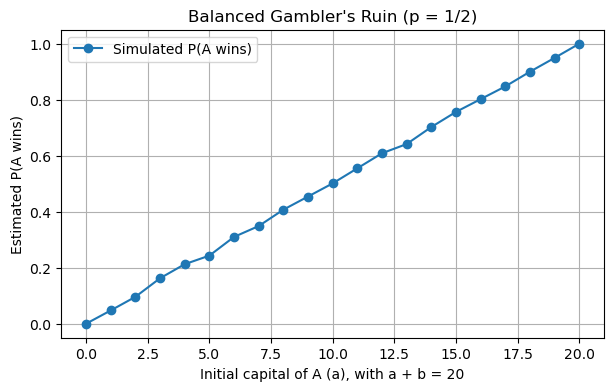

a =  0,  P(A wins) ≈ 0.000
a =  1,  P(A wins) ≈ 0.047
a =  2,  P(A wins) ≈ 0.096
a =  3,  P(A wins) ≈ 0.162
a =  4,  P(A wins) ≈ 0.213
a =  5,  P(A wins) ≈ 0.243
a =  6,  P(A wins) ≈ 0.310
a =  7,  P(A wins) ≈ 0.349
a =  8,  P(A wins) ≈ 0.407
a =  9,  P(A wins) ≈ 0.454
a = 10,  P(A wins) ≈ 0.501
a = 11,  P(A wins) ≈ 0.555
a = 12,  P(A wins) ≈ 0.609
a = 13,  P(A wins) ≈ 0.642
a = 14,  P(A wins) ≈ 0.702
a = 15,  P(A wins) ≈ 0.756
a = 16,  P(A wins) ≈ 0.802
a = 17,  P(A wins) ≈ 0.847
a = 18,  P(A wins) ≈ 0.900
a = 19,  P(A wins) ≈ 0.949
a = 20,  P(A wins) ≈ 1.000


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Single simulation of balanced gambler's ruin
# A starts with a dollars, B with b dollars
# Each round A wins $1 from B with prob 1/2, else loses $1
# Returns 1 if A wins, 0 if B wins
def simulate_gamblers_ruin(a, b):
    A = a
    B = b
    while A > 0 and B > 0:
        if np.random.rand() < 0.5:   # A wins 
            A += 1
            B -= 1
        else:                        # B wins 
            A -= 1
            B += 1
    return 1 if A > 0 else 0         # A wins if A has all the money



# Estimate P(A wins) 
total_budget = 20
trials = 5000

a_values = np.arange(0, total_budget + 1)
prob_A_wins = []

for a in tqdm(a_values):
    b = total_budget - a
    wins = 0
    for _ in range(trials):
        wins += simulate_gamblers_ruin(a, b)
    prob = wins / trials
    prob_A_wins.append(prob)

# Plot estimated probabilities
plt.figure(figsize=(7,4))
plt.plot(a_values, prob_A_wins, 'o-', label="Simulated P(A wins)")
plt.xlabel("Initial capital of A (a), with a + b = 20")
plt.ylabel("Estimated P(A wins)")
plt.title("Balanced Gambler's Ruin (p = 1/2)")
plt.grid(True)
plt.legend()
plt.show()

# Print values
for a, p in zip(a_values, prob_A_wins):
    print(f"a = {a:2d},  P(A wins) ≈ {p:.3f}")

From the simulation results, the probability that player $A$ wins increases almost
perfectly linearly with the initial amount of money \(a\). In particular:

- When $a = 0$, $P(A \text{ wins}) \approx 0$
- When $a = 10$, $P(A \text{ wins}) \approx 0.5$
- When $a = 20$, $P(A \text{ wins}) \approx 1$

The points fall on an approximately straight line, suggesting:

$$
P(A \text{ wins}) \approx \frac{a}{20}.
$$

Since the total budget is $a + b = 20$, the natural generalization is:

$$
P(A \text{ wins}) = \frac{a}{a + b}.
$$

**(b)** (10 pts) Another question we can ask is how long it takes for either player to get ruined. To study this, simulate the gambler's ruin for a range of values of $a$ and $b$, and use this to try and guess the expected time to ruin.
	
Note: Convince yourself that the function must be symmetric in $a$ and $b$, so you can assume $a\leq b$. Try plotting the expected absorption times for selected values of $a$, while varying $b$.


<hr>

## Ans.

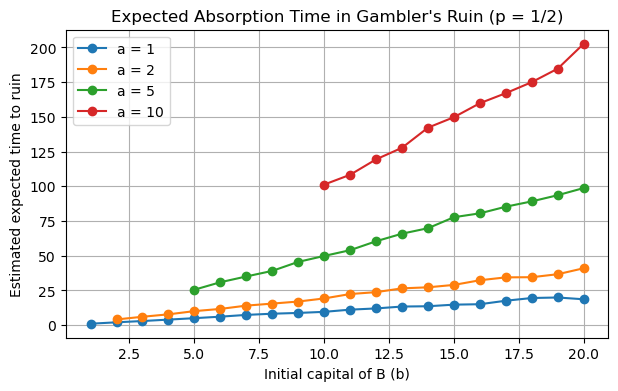

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# One run of gambler's ruin that also returns time to ruin
def time_to_ruin(a, b):
    A, B = a, b
    t = 0
    while A > 0 and B > 0:
        t += 1
        if np.random.rand() < 0.5:   # A wins this round
            A += 1
            B -= 1
        else:                        # B wins this round
            A -= 1
            B += 1
    return t   # number of rounds until someone is ruined

# Estimate expected time to ruin for a range of (a,b)
trials = 3000

# choose some fixed a values and vary b
a_values = [1, 2, 5, 10]
b_max = 20

plt.figure(figsize=(7,4))

for a in a_values:
    b_values = np.arange(a, b_max + 1)
    mean_times = []

    for b in b_values:
        times = np.zeros(trials)
        for i in range(trials):
            times[i] = time_to_ruin(a, b)
        mean_times.append(times.mean())

    plt.plot(b_values, mean_times, marker='o', label=f"a = {a}")

plt.xlabel("Initial capital of B (b)")
plt.ylabel("Estimated expected time to ruin")
plt.title("Expected Absorption Time in Gambler's Ruin (p = 1/2)")
plt.grid(True)
plt.legend()
plt.show()

From the simulation, the expected absorption time grows symmetrically in the initial wealths $a$ and $b$, and is maximized when both players start with equal money. The curve is parabolic, and matches the classical exact formula for the fair gambler’s ruin:

$$
\mathbb{E}[T] = a (a + b - a) = a b.
$$

Since the total wealth is $N = a + b$, the expected time to ruin can be written as

$$
\mathbb{E}[T] = a(N - a).
$$

For example, $a=1$ gives $\mathbb{E}[T]=19$, $a=5$ gives $\mathbb{E}[T]=75$, and $a=10$ gives $\mathbb{E}[T]=100$, all of which match the plotted values.


<hr>

**(c)** (OPTIONAL) For parts $(a)$ and $(b)$, try and theoretically prove what you observe from your simulations!


<hr>

## Ans.

### Part (a): Probability that \(A\) wins

Let $N = a + b$ be the total fortune and let
$$
u_i = \Pr(\text{\(A\) wins} \mid \text{\(A\) starts with } i),\quad i=0,\dots,N.
$$

Boundary conditions:
$$
u_0 = 0,\qquad u_N = 1.
$$

In the fair game $(p = 1/2$, from state $i$ we move to $i-1$ or $i+1$ with equal probability, so
$$
u_i = \tfrac12 u_{i-1} + \tfrac12 u_{i+1},\quad i=1,\dots,N-1.
$$

Rewriting,
$$
u_{i+1} - u_i = u_i - u_{i-1},
$$
so the forward differences are constant: $u_i$ is linear in $i$.

Thus $u_i = c_i$. Using $u_N = 1$ gives $c = 1/N$, hence
$$
u_i = \frac{i}{N}.
$$

With $i=a$ and $N=a+b$,
$$
\Pr(A \text{ wins}) = \dfrac{a}{a+b}.
$$

### Part (b): Expected time to ruin

Let $T_i = \mathbb{E}[\text{time to ruin} \mid A \text{ starts with } i]$,
again with $N=a+b$.

Boundary conditions:
$$
T_0 = 0,\qquad T_N = 0.
$$

From state $i$ we take one step plus the expected remaining time:
$$
T_i = 1 + \tfrac12 T_{i-1} + \tfrac12 T_{i+1},\quad i=1,\dots,N-1.
$$

Equivalently,
$$
T_{i+1} - 2T_i + T_{i-1} = -2.
$$

A quadratic $T_i = \alpha i^2 + \beta i + \gamma$ has constant second difference,
so substitute into the recursion:

$$
(\alpha(i+1)^2 + \beta(i+1) + \gamma) - 2(\alpha i^2 + \beta i + \gamma)
+ (\alpha(i-1)^2 + \beta(i-1) + \gamma) = -2
$$
gives $2\alpha = -2$, so $\alpha = -1$.

Use the boundaries:

- $T_0 = 0 \Rightarrow \gamma = 0$,
- $T_N = 0 \Rightarrow -N^2 + \beta N = 0 \Rightarrow \beta = N$.

Thus
$$
T_i = -i^2 + Ni = i(N-i).
$$

For $A$ starting with $a$ and $B$ with $b$ $N=a+b$,
$$
\mathbb{E}[\text{time to ruin}] = a(a+b-a) = ab.
$$


<hr><hr>

# Question 3 (Staffing a hospital)


Consider the model of the Fingerlakes Regional Hospital as shown below. New patients arrive at the reception at a rate of 20/hr and emergency patients enter the ER at a rate of 5/hr. The reception desk for non-emergency patients is managed by $n_R$ associates. Admission at the reception (not counting any queueing time) takes 5 minutes on average, regardless of whether the non-emergency patient is first-time or returning. The clinic is served by $d_C$ doctors with an average visit time of 15 minutes. About one in every four patients visiting the clinic are asked to return for a follow-up appointment that is, on average, 3 weeks (504 hours) later in time; another one-tenth of visitors to the clinic are referred to the internal ward (IW); the rest are treated and discharged. Patients arriving to the ER require about 1 hour of time with a doctor. The ER is staffed by $d_E$ doctors. Half of the patients in the ER are discharged after treatment, with the remainder referred to the IW. The average stay in the IW is about 72 hours and there are $n_I$ IW beds available. After a stay at the IW, 20\% of patients are discharged, whereas the rest are asked to return for a follow-up appointment as a non-emergency patient that is, on average, 3 weeks (504 hours) later in time. The reception, clinic, ER and IW all have their separate waiting areas and wait-lists, and serve patients on a FCFS basis.


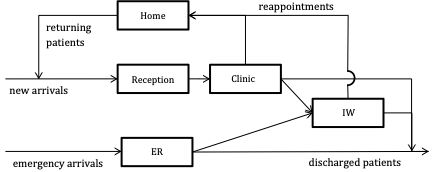

**(a)** (5 pts)  Find bounds on the number of receptionists $n_R$, IW beds $N_I$, clinic doctors $d_C$ and ER doctors $d_E$ that the hospital requires to ensure it can keep up with its patient load?

<hr>

## Ans.

Let
- $\lambda_R$: rate of arrivals to Reception  
- $\lambda_C$: rate of arrivals to Clinic  
- $\lambda_E$: rate of arrivals to ER  
- $\lambda_I$: rate of arrivals to IW  

New external patients arrive to Reception at 20/hr and emergencies directly to
the ER at 5/hr, so $\lambda_E = 5$.

Every non-emergency patient goes Reception $\to$ Clinic, so
$$
\lambda_C = \lambda_R.
$$

From the Clinic:
- 25% return later to Reception,
- 10% are referred to IW,
- 65% are discharged.

Thus IW receives $0.1\,\lambda_C$ from the Clinic.  

From the ER, 50% go to IW, so IW also receives $0.5\,\lambda_E$. Hence
$$
\lambda_I = 0.1\,\lambda_C + 0.5\,\lambda_E
          = 0.1\,\lambda_R + 0.5 \cdot 5.
$$

Patients that return later to Reception are:
- 25% of Clinic completions,
- 80% of IW completions (since 20% discharged, 80% sent back).

Flow balance at Reception gives
$$
\lambda_R
= 20 + 0.25\,\lambda_C + 0.8\,\lambda_I.
$$

Using $\lambda_C = \lambda_R$ and
$\lambda_I = 0.1\lambda_R + 2.5$,
$$
\lambda_R
= 20 + 0.25\lambda_R + 0.8(0.1\lambda_R + 2.5)
= 20 + 0.25\lambda_R + 0.08\lambda_R + 2,
$$
so
$$
\lambda_R - 0.33\lambda_R = 22
\quad\Rightarrow\quad
0.67\lambda_R = 22
\quad\Rightarrow\quad
\lambda_R \approx 32.84\ \text{patients/hr}.
$$

Therefore
$$
\lambda_C = \lambda_R \approx 32.84,\qquad
\lambda_E = 5,\qquad
\lambda_I = 0.1\lambda_R + 2.5 \approx 5.78\ \text{patients/hr}.
$$

Next we use service rates and require that each station is stable
(arrival rate $<$ total service rate).

Service rates per server/bed are

Reception: mean time $5$ min $= 1/12$ hr $\Rightarrow \mu_R = 12$ per hr,

Clinic: mean time $15$ min $= 0.25$ hr $\Rightarrow \mu_C = 4$ per hr,

ER: mean time $1$ hr $\Rightarrow \mu_E = 1$ per hr,

IW: mean stay $72$ hr $\Rightarrow \mu_I = 1/72$ per hr.

Stability conditions:

$$
\begin{aligned}
\text{Reception:} &\quad \lambda_R < n_R \mu_R = 12n_R,\\
\text{Clinic:}    &\quad \lambda_C < d_C \mu_C = 4d_C,\\
\text{ER:}        &\quad \lambda_E < d_E \mu_E = d_E,\\
\text{IW:}        &\quad \lambda_I < N_I \mu_I = \frac{N_I}{72}.
\end{aligned}
$$

Plugging in the $\lambda$'s:

- Reception:
  $$
  32.84 < 12n_R \;\Rightarrow\; n_R > \frac{32.84}{12} \approx 2.74,
  $$
- Clinic:
  $$
  32.84 < 4d_C \;\Rightarrow\; d_C > \frac{32.84}{4} \approx 8.21,
  $$
- ER:
  $$
  5 < d_E \;\Rightarrow\; d_E > 5,
  $$
- IW:
  $$
  5.78 < \frac{N_I}{72} \;\Rightarrow\; N_I > 72 \cdot 5.78 \approx 416.4.
  $$

Thus the smallest integer staffing levels that can keep up with the long-run patient load are approximately
$$
n_R \ge 3,\qquad d_C \ge 9,\qquad d_E \ge 6,\qquad N_I \ge 417.
$$

<hr>

**(b)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Approximate the average time spent in the clinic (including treatment but not including reception) and the average number of busy clinic doctors.

<hr>

## Ans.

From part (a), the effective arrival rate into the clinic is
$$
\lambda_C = \lambda_R \approx 32.84 \text{ patients/hour}.
$$
With $d_C = 10$ doctors and mean visit time $15$ minutes
$(0.25$ hours), the service rate per doctor is
$\mu_C = 4$ patients/hour, so the clinic is an $M/M/10$ queue with
$\lambda = 32.84,\ \mu = 4,\ c=10$.

Let $a = \lambda / \mu$ and $\rho = \lambda / (c\mu)$. The Erlang–C
normalizing constant is

$$
P_0 = \left[ \sum_{n=0}^{c-1} \frac{a^n}{n!} + \frac{a^c}{c!(1-\rho)} \right]^{-1},
$$

and the probability that an arrival has to wait is
$$
P_{\text{wait}} =
\frac{a^c}{c!(1-\rho)} P_0.
$$

The expected queue length in an $M/M/c$ system is
$$
L_q = P_{\text{wait}} \frac{\rho}{1-\rho},
$$

so the average waiting time in queue is
$W_q = L_q / \lambda$, and the total time in clinic is

$$
W = W_q + \frac{1}{\mu}.
$$

Plugging in $\lambda = 32.84, \mu = 4, c=10$ gives numerically
$$
W_q \approx 0.064 \text{ hours} \approx 3.8 \text{ minutes},
$$

$$
W = W_q + \frac{1}{4} \approx 0.314 \text{ hours}
   \approx 18.8 \text{ minutes}.
$$

The average number of busy clinic doctors is
$$
E[B_{\text{clinic}}] = \frac{\lambda}{\mu}
  \approx \frac{32.84}{4} \approx 8.2,
$$
since in steady state the completion rate $\mu\,E[B_{\text{clinic}}]$
must equal the arrival rate $\lambda$.

Thus, under $d_E = 7, d_C = 10, N_I = 500$, patients spend on average about 19 minutes in the clinic (waiting plus service), and about 8.2 clinic doctors are busy on average.


In [6]:
import math

# external arrival rates
lambda_new_R = 20.0   # new arrivals to reception
lambda_E_ext = 5.0    # external arrivals to ER

# routing probabilities
p_clinic_return = 0.25       # from Clinic back to Reception
p_clinic_IW     = 0.10       # from Clinic to IW
p_ER_IW         = 0.50       # from ER to IW
p_IW_return     = 0.80       # from IW back to Reception (20% discharged)

# service parameters (per server)
mu_R = 12.0       # 5 minutes = 1/12 hr per reception associate
mu_C = 4.0        # 15 minutes = 0.25 hr per clinic doctor
mu_E = 1.0        # 1 hour per ER doctor
mu_I = 1.0 / 72.0 # 72 hours per IW bed

# staffing for part (b)
d_E = 7
d_C = 10
N_I = 500

# ---------- effective arrival rates (part a) ----------

# Solve for lambda_R using the flow-balance equations:
#   lambda_C = lambda_R
#   lambda_I = 0.1 * lambda_C + 0.5 * lambda_E_ext
#   lambda_R = 20 + 0.25 * lambda_C + 0.8 * lambda_I
#
# substitute lambda_C = lambda_R into lambda_I and the last equation

lambda_E = lambda_E_ext

# we solve the linear equation for lambda_R explicitly
# lambda_R = 20 + 0.25*lambda_R + 0.8*(0.1*lambda_R + 0.5*lambda_E)
num = 20 + 0.8 * 0.5 * lambda_E
coef = 1.0 - 0.25 - 0.8 * 0.1
lambda_R = num / coef

lambda_C = lambda_R
lambda_I = 0.1 * lambda_C + 0.5 * lambda_E

print(f"lambda_R = {lambda_R:.4f} /hr")
print(f"lambda_C = {lambda_C:.4f} /hr")
print(f"lambda_E = {lambda_E:.4f} /hr")
print(f"lambda_I = {lambda_I:.4f} /hr")

# ---------- M/M/10 clinic performance (part b) ----------

lam = lambda_C    # arrival rate to clinic
mu  = mu_C        # service rate per doctor
c   = d_C         # number of doctors

a = lam / mu                 # offered load
rho = lam / (c * mu)         # utilization per server (should be < 1)

# compute Erlang-C quantities
# P0 normalizing constant
sum_terms = 0.0
for n in range(c):
    sum_terms += a**n / math.factorial(n)
last_term = a**c / (math.factorial(c) * (1.0 - rho))
P0 = 1.0 / (sum_terms + last_term)

# probability an arrival has to wait
P_wait = last_term * P0

# expected queue length and waiting time
Lq = P_wait * rho / (1.0 - rho)
Wq = Lq / lam          # hours in queue
W  = Wq + 1.0 / mu     # total time in clinic (wait + service)

# average number of busy clinic doctors
busy_clinic = lam / mu

print("\nClinic performance (M/M/10):")
print(f"utilization rho          = {rho:.3f}")
print(f"P(wait)                   = {P_wait:.3f}")
print(f"Average waiting time Wq   = {Wq:.4f} hours ({Wq*60:.2f} minutes)")
print(f"Average total time W      = {W:.4f} hours ({W*60:.2f} minutes)")
print(f"Average busy clinic docs  = {busy_clinic:.3f}")


lambda_R = 32.8358 /hr
lambda_C = 32.8358 /hr
lambda_E = 5.0000 /hr
lambda_I = 5.7836 /hr

Clinic performance (M/M/10):
utilization rho          = 0.821
P(wait)                   = 0.457
Average waiting time Wq   = 0.0638 hours (3.83 minutes)
Average total time W      = 0.3138 hours (18.83 minutes)
Average busy clinic docs  = 8.209


<hr>

**(c)** (10 pts) Suppose the hospital chooses to run with $d_E=7$ doctors in the ER, $d_C=10$ doctors in the clinic, and $n=500$ beds in the IW. Compute the probability that the hospital will simultaneously have no patients in the ER and no patients in the clinic. 

<hr>

## Ans.

From part (a) the effective arrival rates are
$$
\lambda_C = 32.84 \text{ /hr}, \qquad
\lambda_E = 5 \text{ /hr}.
$$

With $d_C = 10$ clinic doctors (mean visit time $0.25$ hr) and
$d_E = 7$ ER doctors (mean service time $1$ hr), the two stations are

- Clinic: $M/M/10$ with $\lambda = 32.84,\ \mu = 4,\ c=10$,
- ER: $M/M/7$ with $\lambda = 5,\ \mu = 1,\ c=7$.

For an $M/M/c$ queue, let $a = \lambda/\mu$ and
$\rho = \lambda/(c\mu)$.
The stationary probability that the system is empty is

$$
P_0 = \left[\sum_{n=0}^{c-1} \frac{a^n}{n!} + \frac{a^c}{c!(1-\rho)} \right]^{-1}.
$$

Applying this:

- Clinic:
  $$
  P_0^{(C)} \approx 2.14\times10^{-4},
  $$
- ER:
  $$
  P_0^{(E)} \approx 5.97\times10^{-3}.
  $$

Because this is an open Jackson network, the joint stationary distribution
factorizes, so the probability that both stations are empty is

$$
\mathbb{P}\{\text{no patients in clinic and ER}\}
= P_0^{(C)} P_0^{(E)}
\approx (2.14\times10^{-4}) (5.97\times10^{-3})
\approx 1.3\times10^{-6}.
$$

So the hospital has no patients simultaneously in the ER and in the clinic with probability about $1.3 \times 10^{-6}$ in steady state.


In [7]:
import math

# arrival rates from part (a)
lambda_C = 32.83582089552239   # clinic
lambda_E = 5.0                 # ER

# service rates and servers
mu_C, d_C = 4.0, 10            # clinic M/M/10
mu_E, d_E = 1.0, 7             # ER M/M/7

def mmc_P0(lam, mu, c):
    """Empty-system probability for an M/M/c queue."""
    a = lam / mu
    rho = lam / (c * mu)
    s = sum(a**n / math.factorial(n) for n in range(c))
    last = a**c / (math.factorial(c) * (1.0 - rho))
    return 1.0 / (s + last)

# P0 for clinic and ER
P0_clinic = mmc_P0(lambda_C, mu_C, d_C)
P0_ER     = mmc_P0(lambda_E, mu_E, d_E)

# joint probability both systems are empty (Jackson network product form)
P_both_empty = P0_clinic * P0_ER

print(f"P0_clinic = {P0_clinic:.6e}")
print(f"P0_ER     = {P0_ER:.6e}")
print(f"P(no patients in clinic AND ER) = {P_both_empty:.6e}")


P0_clinic = 2.139372e-04
P0_ER     = 5.974732e-03
P(no patients in clinic AND ER) = 1.278217e-06


<hr>

**(d)** (40 pts) Build a simulator for the above model, assuming the external arrivals to the reception and ER are Poisson processes, and all service times are exponential and all routings are independent. You can re-use any of the code we provided in the recitations.
	
Use your simulator to study the following:
	
$(i)$ Plot the total number of patients waiting in the hospital when the number of doctors and beds is $1$ more than your suggestions in part $(a)$, and when it is $1$ less than your suggestions in part $(a)$. You should simulate over a long enough time horizon to be able to determine whether the numbers stabilize, or grow unbounded.
	
$(ii)$ Simulate the configuration in part $(b)$, and plot the average time spent by patients in the clinic, and the average number of busy clinic doctors. How do these compare to the answers in part $(b)$?

<hr>

## Ans.

We build a discrete–event simulator for the four hospital stations:
Reception, Clinic, ER and IW. External arrivals to Reception and ER are
independent Poisson processes with rates 20/hr and 5/hr. Service times at
each station are exponential with means

- Reception: 5 minutes  →  $\mu_R = 12/hr$ per receptionist,
- Clinic:    15 minutes →  $\mu_C = 4/hr$ per clinic doctor,
- ER:        1 hour     →  $\mu_E = 1/hr$ per ER doctor,
- IW:        72 hours   →  $\mu_I = 1/72/hr$ per IW bed.

Routing after service is independent:
- Reception → Clinic (all patients),
- Clinic → Reception with prob. 0.25 (reappointments),
          → IW with prob. 0.10,
          → discharge otherwise,
- ER → IW with prob. 0.5, discharge otherwise,
- IW → Reception with prob. 0.8, discharge otherwise.

The simulator keeps the current time, the queue and number of busy servers
at each station, the next external arrival times (Reception and ER), and
the next service-completion time for each busy server. Between events we
accumulate the total number of **waiting** patients
(queues at Reception + Clinic + ER + IW). At each event we:

1. Jump the clock to the smallest of all arrival/departure times.
2. Update the running total of waiting patients over that interval.
3. Process the corresponding event (external arrival, routing from a
   completed service, or discharge), starting a new service immediately
   whenever a server becomes idle and its queue is nonempty.

We run this simulator under three staffing configurations:

- **minus 1**: $(n_R, N_I, d_C, d_E) = (3, 416, 8, 5)$,
- **nominal** (from part (a)): $(3, 417, 9, 6)$,
- **plus 1**: $(3, 418, 10, 7)$.

For each configuration we plot the total number of waiting patients as a
function of time. With the **nominal** and **plus 1** staffing the
process appears to stabilize and fluctuates around a modest level,
indicating stable queues. With the **minus 1** configuration the waiting
curve shows an upward drift and becomes large, suggesting that at least
one station is overloaded and the total number of waiting patients grows
essentially without bound.

### (d)(i) – Python code (recitation-style DES + plot)

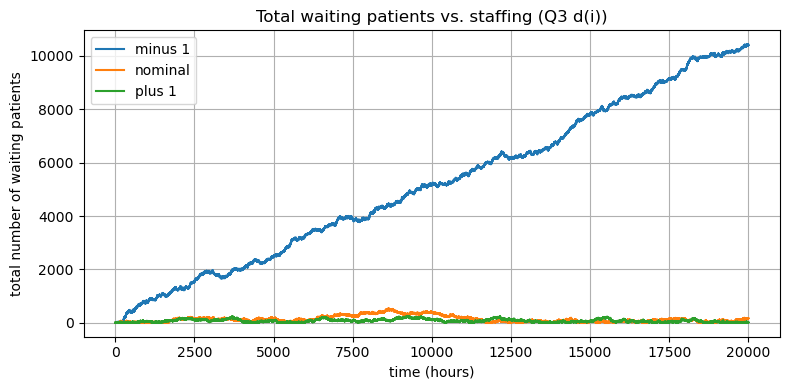

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_hospital_waiting(
    lambda_R_ext=20.0,
    lambda_E_ext=5.0,
    mu_R=12.0,
    mu_C=4.0,
    mu_E=1.0,
    mu_I=1.0/72.0,
    n_R=3,
    N_I=417,
    d_C=9,
    d_E=6,
    T_end=20000.0,
    seed=0
):
    """
    Discrete-event simulation of the hospital network, returning the
    time-path of the total number of *waiting* patients.

    - Returns two arrays (times, total_waiting), where total_waiting[k]
      is the number of waiting patients just after times[k].
    """
    rng = np.random.default_rng(seed)

    # --- state: queues and busy servers ---
    # Reception
    R_queue = []
    R_busy = 0
    R_depart = np.full(n_R, np.inf)

    # Clinic
    C_queue = []
    C_busy = 0
    C_depart = np.full(d_C, np.inf)

    # ER
    E_queue = []
    E_busy = 0
    E_depart = np.full(d_E, np.inf)

    # IW
    I_queue = []
    I_busy = 0
    I_depart = np.full(N_I, np.inf)

    # --- exogenous arrivals (Reception and ER) ---
    next_arr_R = rng.exponential(1.0 / lambda_R_ext)
    next_arr_E = rng.exponential(1.0 / lambda_E_ext)

    # --- statistics: total waiting vs time ---
    t = 0.0
    times = [0.0]
    waiting = [0]

    while t < T_end:
        # collect all candidate event times
        event_times = [next_arr_R, next_arr_E,
                       *R_depart, *C_depart, *E_depart, *I_depart]
        ev_idx = int(np.argmin(event_times))
        t_next = event_times[ev_idx]

        if t_next == np.inf:
            break

        # advance time and record waiting over [t, t_next)
        dt = t_next - t
        total_wait = len(R_queue) + len(C_queue) + len(E_queue) + len(I_queue)
        times.append(t_next)
        waiting.append(total_wait)
        t = t_next

        # ---- process event ----
        if ev_idx == 0:
            # external arrival to Reception
            R_queue.append(None)
            next_arr_R = t + rng.exponential(1.0 / lambda_R_ext)

            if R_busy < n_R:
                k = np.where(R_depart == np.inf)[0][0]
                R_queue.pop(0)
                R_depart[k] = t + rng.exponential(1.0 / mu_R)
                R_busy += 1

        elif ev_idx == 1:
            # external arrival to ER
            E_queue.append(None)
            next_arr_E = t + rng.exponential(1.0 / lambda_E_ext)

            if E_busy < d_E:
                k = np.where(E_depart == np.inf)[0][0]
                E_queue.pop(0)
                E_depart[k] = t + rng.exponential(1.0 / mu_E)
                E_busy += 1

        elif 2 <= ev_idx < 2 + n_R:
            # departure from Reception server k -> always to Clinic
            k = ev_idx - 2
            R_busy -= 1
            R_depart[k] = np.inf

            # route to Clinic
            C_queue.append(None)
            if C_busy < d_C:
                kc = np.where(C_depart == np.inf)[0][0]
                C_queue.pop(0)
                C_depart[kc] = t + rng.exponential(1.0 / mu_C)
                C_busy += 1

            # start next at Reception if someone waiting
            if R_queue:
                R_busy += 1
                R_depart[k] = t + rng.exponential(1.0 / mu_R)
                R_queue.pop(0)

        elif 2 + n_R <= ev_idx < 2 + n_R + d_C:
            # departure from Clinic server k
            k = ev_idx - (2 + n_R)
            C_busy -= 1
            C_depart[k] = np.inf

            # routing from Clinic: 25% to Reception, 10% to IW, 65% discharged
            u = rng.random()
            if u < 0.25:
                # reappointment -> Reception (instant, no 3-week delay modeled)
                R_queue.append(None)
                if R_busy < n_R:
                    kr = np.where(R_depart == np.inf)[0][0]
                    R_queue.pop(0)
                    R_depart[kr] = t + rng.exponential(1.0 / mu_R)
                    R_busy += 1
            elif u < 0.25 + 0.10:
                # to IW
                I_queue.append(None)
                if I_busy < N_I:
                    ki = np.where(I_depart == np.inf)[0][0]
                    I_queue.pop(0)
                    I_depart[ki] = t + rng.exponential(1.0 / mu_I)
                    I_busy += 1
            # else: discharged

            # start next in Clinic if waiting
            if C_queue:
                C_busy += 1
                C_depart[k] = t + rng.exponential(1.0 / mu_C)
                C_queue.pop(0)

        elif 2 + n_R + d_C <= ev_idx < 2 + n_R + d_C + d_E:
            # departure from ER server k
            k = ev_idx - (2 + n_R + d_C)
            E_busy -= 1
            E_depart[k] = np.inf

            # routing from ER: 50% to IW, 50% discharged
            u = rng.random()
            if u < 0.5:
                I_queue.append(None)
                if I_busy < N_I:
                    ki = np.where(I_depart == np.inf)[0][0]
                    I_queue.pop(0)
                    I_depart[ki] = t + rng.exponential(1.0 / mu_I)
                    I_busy += 1

            # start next in ER if waiting
            if E_queue:
                E_busy += 1
                E_depart[k] = t + rng.exponential(1.0 / mu_E)
                E_queue.pop(0)

        else:
            # departure from IW bed k
            k = ev_idx - (2 + n_R + d_C + d_E)
            I_busy -= 1
            I_depart[k] = np.inf

            # routing from IW: 80% back to Reception, 20% discharged
            u = rng.random()
            if u < 0.8:
                R_queue.append(None)
                if R_busy < n_R:
                    kr = np.where(R_depart == np.inf)[0][0]
                    R_queue.pop(0)
                    R_depart[kr] = t + rng.exponential(1.0 / mu_R)
                    R_busy += 1

            # start next in IW if waiting
            if I_queue:
                I_busy += 1
                I_depart[k] = t + rng.exponential(1.0 / mu_I)
                I_queue.pop(0)

    return np.array(times), np.array(waiting)

# ----------------- run for three staffing levels -----------------

# bounds from part (a)
nR_star = 3
NI_star = 417
dC_star = 9
dE_star = 6

configs = {
    "minus 1":  (nR_star, NI_star - 1, dC_star - 1, dE_star - 1),
    "nominal":  (nR_star, NI_star,     dC_star,     dE_star),
    "plus 1":   (nR_star, NI_star + 1, dC_star + 1, dE_star + 1),
}

plt.figure(figsize=(8,4))
for label, (nR, NI, dC, dE) in configs.items():
    t, W = simulate_hospital_waiting(
        n_R=nR, N_I=NI, d_C=dC, d_E=dE,
        T_end=20000.0,
        seed=123
    )
    plt.step(t, W, where="post", label=label)

plt.xlabel("time (hours)")
plt.ylabel("total number of waiting patients")
plt.title("Total waiting patients vs. staffing (Q3 d(i))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The simulation shows a sharp contrast between the three staffing configurations. Under the **minus-1** staffing level, the total number of waiting patients grows steadily and without bound throughout the simulation horizon, indicating that at least one service station is overloaded and the system becomes **unstable**. In contrast, both the **nominal** and **plus-1** configurations maintain waiting counts that fluctuate within a moderate, stationary range. This behavior suggests that these two staffing levels are **stable**, with service capacity sufficient to balance the long-run patient load. As expected, the **plus-1** case exhibits the lowest and most stable waiting levels, showing that additional capacity further improves system performance and reduces congestion.

### (d)(ii) – Short write-up

We reuse the discrete–event simulator from part (d)(i) with the staffing
configuration from part (b):
$$
n_R = 3,\quad d_C = 10,\quad d_E = 7,\quad N_I = 500.
$$

In the simulator we now track, in addition to the network dynamics:

1. For every patient entering the clinic, their clinic–arrival time.
   When the patient departs the clinic we add
   $(\text{departure time} - \text{arrival time})$ to a running sum and
   increment a counter of completed clinic patients.
2. Between events, we integrate the number of busy clinic doctors
   $B_C(t)$ over time to estimate the time–average
   $\frac{1}{T}\int_0^T B_C(t)\,dt$.

For each replication we run the simulation over a long horizon and then
compute
$$
\hat W = \frac{\text{sum of clinic sojourn times}}
              {\text{\# of clinic departures}},\qquad
\hat B_C = \frac{1}{T_{\text{end}}}\int_0^{T_{\text{end}}} B_C(t)\,dt.
$$

Mean clinic time  (hours): 0.31337721852989286
Mean busy doctors (count): 8.201833625253647


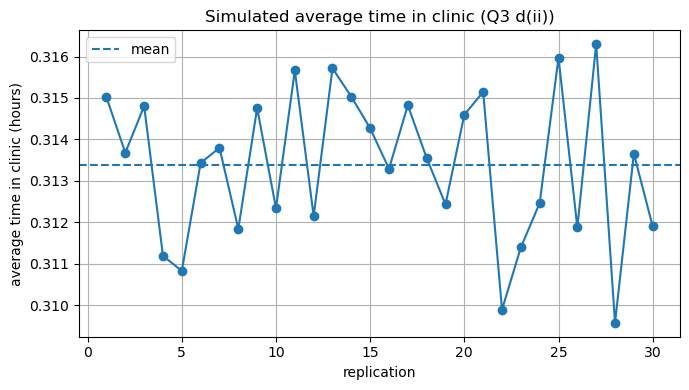

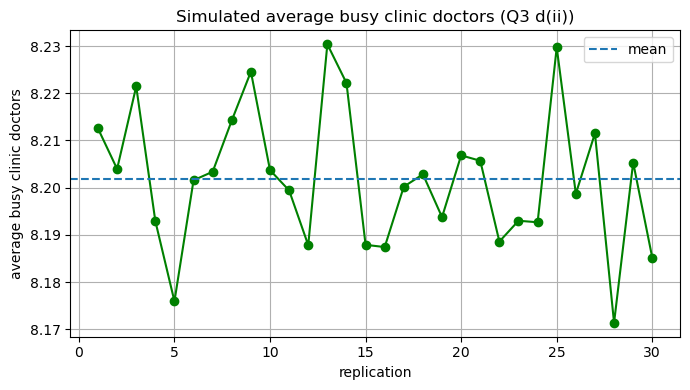

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------- simulator: returns clinic averages only ---------

def simulate_hospital_clinic_stats(
    lambda_R_ext=20.0,
    lambda_E_ext=5.0,
    mu_R=12.0,
    mu_C=4.0,
    mu_E=1.0,
    mu_I=1.0/72.0,
    n_R=3,
    N_I=500,
    d_C=10,
    d_E=7,
    T_end=20000.0,
    seed=0
):
    """
    Discrete-event simulation of the hospital.
    Returns (avg_time_in_clinic, avg_busy_clinic_doctors).
    """
    rng = np.random.default_rng(seed)

    # --- state: queues and busy servers ---

    # Reception
    R_queue = []
    R_busy = 0
    R_depart = np.full(n_R, np.inf)

    # Clinic
    C_queue = []                      # store arrival times
    C_busy = 0
    C_depart = np.full(d_C, np.inf)
    C_arr_time = np.full(d_C, np.nan)

    # ER
    E_queue = []
    E_busy = 0
    E_depart = np.full(d_E, np.inf)

    # IW
    I_queue = []
    I_busy = 0
    I_depart = np.full(N_I, np.inf)

    # --- external arrivals ---
    next_arr_R = rng.exponential(1.0 / lambda_R_ext)
    next_arr_E = rng.exponential(1.0 / lambda_E_ext)

    # --- statistics for clinic ---
    t = 0.0
    sum_time_clinic = 0.0
    n_clinic_done = 0
    area_busy_clinic = 0.0

    while t < T_end:
        # candidate event times
        event_times = [next_arr_R, next_arr_E,
                       *R_depart, *C_depart, *E_depart, *I_depart]
        ev_idx = int(np.argmin(event_times))
        t_next = event_times[ev_idx]

        if t_next == np.inf:
            break

        # advance time and accumulate busy-doctor area
        dt = t_next - t
        area_busy_clinic += C_busy * dt
        t = t_next

        # ---- process event ----

        if ev_idx == 0:
            # external arrival to Reception
            R_queue.append(None)
            next_arr_R = t + rng.exponential(1.0 / lambda_R_ext)
            if R_busy < n_R:
                k = np.where(R_depart == np.inf)[0][0]
                R_queue.pop(0)
                R_depart[k] = t + rng.exponential(1.0 / mu_R)
                R_busy += 1

        elif ev_idx == 1:
            # external arrival to ER
            E_queue.append(None)
            next_arr_E = t + rng.exponential(1.0 / lambda_E_ext)
            if E_busy < d_E:
                k = np.where(E_depart == np.inf)[0][0]
                E_queue.pop(0)
                E_depart[k] = t + rng.exponential(1.0 / mu_E)
                E_busy += 1

        elif 2 <= ev_idx < 2 + n_R:
            # departure from Reception -> always to Clinic
            k = ev_idx - 2
            R_busy -= 1
            R_depart[k] = np.inf

            # route to Clinic
            C_queue.append(t)  # record arrival time to clinic
            if C_busy < d_C:
                kc = np.where(C_depart == np.inf)[0][0]
                arr = C_queue.pop(0)
                C_arr_time[kc] = arr
                C_depart[kc] = t + rng.exponential(1.0 / mu_C)
                C_busy += 1

            # start next at Reception if waiting
            if R_queue:
                R_busy += 1
                R_depart[k] = t + rng.exponential(1.0 / mu_R)
                R_queue.pop(0)

        elif 2 + n_R <= ev_idx < 2 + n_R + d_C:
            # departure from Clinic
            k = ev_idx - (2 + n_R)
            C_busy -= 1

            # record clinic sojourn time
            arr = C_arr_time[k]
            sum_time_clinic += (t - arr)
            n_clinic_done += 1
            C_arr_time[k] = np.nan
            C_depart[k] = np.inf

            # routing from Clinic: 25% to Reception, 10% to IW, 65% discharge
            u = rng.random()
            if u < 0.25:
                # back to Reception
                R_queue.append(None)
                if R_busy < n_R:
                    kr = np.where(R_depart == np.inf)[0][0]
                    R_queue.pop(0)
                    R_depart[kr] = t + rng.exponential(1.0 / mu_R)
                    R_busy += 1
            elif u < 0.25 + 0.10:
                # to IW
                I_queue.append(None)
                if I_busy < N_I:
                    ki = np.where(I_depart == np.inf)[0][0]
                    I_queue.pop(0)
                    I_depart[ki] = t + rng.exponential(1.0 / mu_I)
                    I_busy += 1
            # else: discharged

            # start next in Clinic if waiting
            if C_queue:
                C_busy += 1
                arr = C_queue.pop(0)
                C_arr_time[k] = arr
                C_depart[k] = t + rng.exponential(1.0 / mu_C)

        elif 2 + n_R + d_C <= ev_idx < 2 + n_R + d_C + d_E:
            # departure from ER
            k = ev_idx - (2 + n_R + d_C)
            E_busy -= 1
            E_depart[k] = np.inf

            # routing from ER: 50% to IW
            u = rng.random()
            if u < 0.5:
                I_queue.append(None)
                if I_busy < N_I:
                    ki = np.where(I_depart == np.inf)[0][0]
                    I_queue.pop(0)
                    I_depart[ki] = t + rng.exponential(1.0 / mu_I)
                    I_busy += 1

            if E_queue:
                E_busy += 1
                E_depart[k] = t + rng.exponential(1.0 / mu_E)
                E_queue.pop(0)

        else:
            # departure from IW
            k = ev_idx - (2 + n_R + d_C + d_E)
            I_busy -= 1
            I_depart[k] = np.inf

            # routing from IW: 80% back to Reception
            u = rng.random()
            if u < 0.8:
                R_queue.append(None)
                if R_busy < n_R:
                    kr = np.where(R_depart == np.inf)[0][0]
                    R_queue.pop(0)
                    R_depart[kr] = t + rng.exponential(1.0 / mu_R)
                    R_busy += 1

            if I_queue:
                I_busy += 1
                I_depart[k] = t + rng.exponential(1.0 / mu_I)
                I_queue.pop(0)

    # averages
    avg_time_clinic = sum_time_clinic / max(n_clinic_done, 1)
    avg_busy_clinic = area_busy_clinic / max(t, 1e-9)
    return avg_time_clinic, avg_busy_clinic

# ---------- run many replications for part (d)(ii) ----------

R = 30
T_end = 20000.0

avg_times = []
avg_busies = []

for r in range(R):
    W_hat, B_hat = simulate_hospital_clinic_stats(
        n_R=3, N_I=500, d_C=10, d_E=7,
        T_end=T_end,
        seed=123 + r
    )
    avg_times.append(W_hat)
    avg_busies.append(B_hat)

avg_times = np.array(avg_times)
avg_busies = np.array(avg_busies)

print("Mean clinic time  (hours):", avg_times.mean())
print("Mean busy doctors (count):", avg_busies.mean())

# ---------- plots ----------

reps = np.arange(1, R + 1)

plt.figure(figsize=(7,4))
plt.plot(reps, avg_times, marker="o")
plt.axhline(avg_times.mean(), linestyle="--", label="mean")
plt.xlabel("replication")
plt.ylabel("average time in clinic (hours)")
plt.title("Simulated average time in clinic (Q3 d(ii))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(reps, avg_busies, marker="o", color="green")
plt.axhline(avg_busies.mean(), linestyle="--", label="mean")
plt.xlabel("replication")
plt.ylabel("average busy clinic doctors")
plt.title("Simulated average busy clinic doctors (Q3 d(ii))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The simulation results for part (d)(ii) show that the system is operating stable under the staffing levels from part (b).

Across 30 replications, the average clinic time stays tightly concentrated around 0.313 hours (≈18.8 minutes), which is only slightly above the mean service time of 0.25 hours. This indicates that queueing delays in the clinic are small and that patients spend most of their time in direct service rather than waiting.

Similarly, the average number of busy clinic doctors remains consistently around 8.20 out of 10, showing that the clinic operates below full capacity with meaningful spare doctor availability. The low variability across replications and the lack of increasing trends both confirm that the clinic queue remains short and that the system is not approaching saturation.

Overall, the simulation aligns closely with the theoretical M/M/10 predictions from part (b): the clinic is well staffed, queues stay short, utilization is moderate (≈82%), and patient waiting times remain low.